# Verification of Bounded Variance of Stochastic Gradients

### Objective

The objective of this experiment is to verify whether the variance of stochastic gradients remains bounded during training.

A bounded gradient variance ensures that the stochastic updates produced by SGD do not fluctuate excessively, contributing to stable optimization and convergence.

### Methodology

The verification is performed as follows:

1. Initialize the model with fixed parameters.
2. Sample multiple random mini-batches for different batch sizes.
3. Compute the gradient for each mini-batch.
4. Estimate the variance of the stochastic gradients.
5. Analyze how the gradient variance changes with batch size.

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 

from src.utils import load_config
from src.data import get_dataloaders
from manual_nn.models import SimpleCNN

import torch
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F


In [2]:
config = load_config(os.path.join(PROJECT_ROOT, "configs/data.yaml"))
model_cfg = load_config(os.path.join(PROJECT_ROOT, "configs/model.yaml"))

train_loader, _, _ = get_dataloaders(
    data_dir=config["root"],
    batch_size=len(get_dataloaders(
        data_dir=config["root"],
        batch_size=1,
    )[0].dataset),
    shuffle=False,
)

model = SimpleCNN(model_cfg)
loss_fn = CrossEntropyLoss()

In [11]:

batch_sizes = [1,2,4,8,16,32,64,128,256,512]
num_trials = 200

variance_results = {}

for batch_size in batch_sizes:

    loader,_,_ = get_dataloaders(data_dir=config["root"], batch_size=batch_size, shuffle=True)

    gradients = []
    count = 0

    for x,y in tqdm(loader, leave=False):

        model.zero_grad()

        logits = model.forward(x)
        probs = F.softmax(logits, dim=1)
        targets = F.one_hot(y, num_classes=model_cfg["num_classes"]).float()
        grad_logits = (probs-targets)/y.size(0)

        model.backward(grad_logits)

        grad = torch.cat([g.flatten() for g in model.gradients()])
        gradients.append(grad)

        count += 1
        if count == num_trials:
            break

    gradients = torch.stack(gradients)
    mean_grad = gradients.mean(dim=0)

    variance = ((gradients-mean_grad)**2).sum(dim=1).mean()

    variance_results[batch_size] = variance.item()

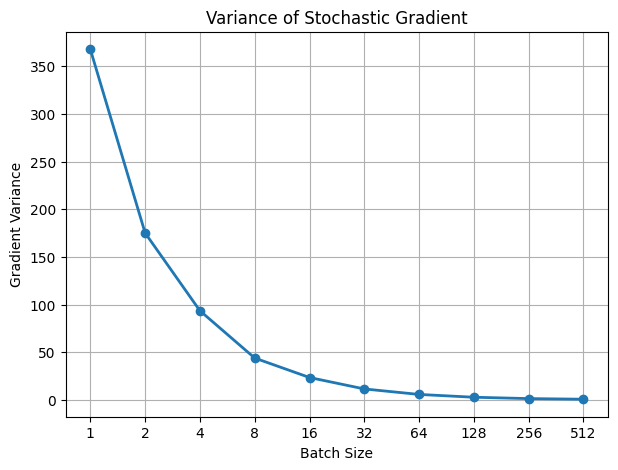

In [9]:
plt.figure(figsize=(7,5))

plt.plot(variance_results.keys(),variance_results.values(),marker="o",linewidth=2)

plt.xscale("log",base=2)
plt.xticks(batch_sizes,batch_sizes)

plt.xlabel("Batch Size")
plt.ylabel("Gradient Variance")
plt.title("Variance of Stochastic Gradient")
plt.grid(True)

plt.show()

### What does this figure tell?

- Small mini-batches exhibit higher gradient variance because fewer samples contribute to each gradient estimate.
- As the batch size increases, the variance decreases since gradients are averaged over more samples.
- The variance remains finite for all evaluated batch sizes.
- These observations support the bounded variance assumption commonly used in SGD convergence analysis.


### Conclusion

The empirical results indicate that the variance of stochastic gradients is bounded and decreases with increasing batch size. Larger mini-batches produce more stable gradient estimates by reducing sampling noise, supporting the bounded variance assumption required for SGD convergence.